<a href="https://colab.research.google.com/github/ginaldoribeiro/Atividade-Especializacao-React/blob/main/classificador_tumores_ISIC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔬 Classificador Multimodal de Tumores — ISIC 2020
**Saída:** Benigno `(0)` | Maligno `(1)`

---
## Estrutura do Notebook
| Parte | Conteúdo |
|---|---|
| **1 — EDA** | Distribuição de classes, features, nulos, pacientes, imagens, pixels |
| **2 — Pré-processamento** | Decisões baseadas na EDA: imputação, encoding, split por paciente |
| **3 — Arquiteturas** | EfficientNet-B0, ResNet-50, MobileNetV3-L, Baseline Tabular |
| **4 — Comparação** | 13 métricas, curvas ROC/PR, matrizes de confusão, radar chart |

> ⚠️ **Recomendado:** Ativar GPU antes de executar → *Editar > Configurações do notebook > GPU*


## ⚙️ Célula 1 — Verificação do Ambiente

In [5]:
# Verifica GPU disponível
!nvidia-smi 2>/dev/null || echo 'GPU não detectada — usando CPU'
import torch
print(f'PyTorch: {torch.__version__}')
print(f'CUDA disponível: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')


Fri Jun  5 01:46:44 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   35C    P8             13W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 📂 Célula 2 — Google Drive
> Faça o upload do `dataset.zip` no seu Drive e ajuste `ZIP_PATH` abaixo.


In [6]:
from google.colab import drive
drive.mount('/content/drive')

# ── Ajuste o caminho conforme onde salvou o arquivo no Drive ──
ZIP_PATH = '/content/drive/MyDrive/dataset.zip'

import os
if os.path.exists(ZIP_PATH):
    print(f'✓ dataset.zip encontrado: {ZIP_PATH}')
else:
    print(f'✗ Arquivo não encontrado: {ZIP_PATH}')
    print('  Verifique o caminho ou faça upload direto com a célula abaixo.')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ dataset.zip encontrado: /content/drive/MyDrive/dataset.zip


### Alternativa: Upload direto (sem Google Drive)
> Execute apenas se **não** montou o Drive.


In [7]:
# OPCIONAL — Execute somente se não usar o Google Drive
# from google.colab import files
# uploaded = files.upload()          # selecione dataset.zip
# ZIP_PATH = list(uploaded.keys())[0]
# print(f'ZIP salvo em: {ZIP_PATH}')


## 📦 Célula 4 — Imports

In [8]:
import os, io, sys, zipfile, random, warnings, time
from copy import deepcopy
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
%matplotlib inline
plt.rcParams['figure.dpi'] = 100

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, log_loss,
    balanced_accuracy_score, matthews_corrcoef,
    brier_score_loss, roc_curve, precision_recall_curve,
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from torchvision.models import efficientnet_b0, resnet50, mobilenet_v3_large
from PIL import Image

print('Imports OK ✓')


Imports OK ✓


## ⚙️ Célula 5 — Configuração Central
> Ajuste `epochs` conforme o tempo disponível. No Colab gratuito, recomenda-se `10–15` épocas.


In [9]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {DEVICE}')

CFG = {
    # Caminhos (ZIP_PATH definido na célula 2)
    'zip_path':    ZIP_PATH,
    'output_dir':  '/content/saida_projeto',

    # Imagem — as originais já são 128×128; fazemos upscale para 224
    'img_size':    224,

    # ── Treinamento ───────────────────────────
    'epochs':      15,          # ↑ aumente para melhor resultado
    'batch_size':  32,
    'lr':          1e-4,
    'weight_decay': 1e-5,
    'dropout':     0.4,
    'pos_weight':  10.0,        # penaliza mais erro em malignos
    'seed':        42,
    'num_workers': 2,           # 2 workers no Colab (melhor que 0)

    # ── Split por paciente ────────────────────
    'test_size':   0.15,
    'val_size':    0.15,

    # ── Threshold de decisão ──────────────────
    # Valor < 0.5 → mais sensível a malignos (recomendado em triagem)
    'threshold':   0.30,
}

def seed_all(s=CFG['seed']):
    random.seed(s); np.random.seed(s); torch.manual_seed(s)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(s)

seed_all()
os.makedirs(CFG['output_dir'], exist_ok=True)
print(f"Saídas em: {CFG['output_dir']}")


Dispositivo: cuda
Saídas em: /content/saida_projeto


---
# 📊 PARTE 1 — Análise Exploratória de Dados (EDA)
> Conforme orientação do projeto: **analisar os dados antes de qualquer decisão de pré-processamento.**


## 1.1 – Carregamento e Visão Geral do Dataset

In [10]:
def carregar_csv(zip_path):
    with zipfile.ZipFile(zip_path, 'r') as zf:
        with zf.open('data.csv') as f:
            return pd.read_csv(f)

df = carregar_csv(CFG['zip_path'])

print(f'Shape: {df.shape}')
print(f'\nColunas e tipos:')
print(df.dtypes)
print(f'\nPrimeiras linhas:')
df.head()


Shape: (33126, 8)

Colunas e tipos:
image_name                        object
patient_id                        object
sex                               object
age_approx                       float64
anatom_site_general_challenge     object
diagnosis                         object
benign_malignant                  object
target                             int64
dtype: object

Primeiras linhas:


,image_name,patient_id,sex,age_approx,anatom_site_general_challenge,diagnosis,benign_malignant,target
0,ISIC_2637011,IP_7279968,male,45.0,head/neck,unknown,benign,0
1,ISIC_0015719,IP_3075186,female,45.0,upper extremity,unknown,benign,0
2,ISIC_0052212,IP_2842074,female,50.0,lower extremity,nevus,benign,0
3,ISIC_0068279,IP_6890425,female,45.0,head/neck,unknown,benign,0
4,ISIC_0074268,IP_8723313,female,55.0,upper extremity,unknown,benign,0


## 1.2 – Distribuição de Classes e Desbalanceamento

  DISTRIBUIÇÃO DE CLASSES
  Total   : 33,126
  Benigno : 32,542  (98.24%)
  Maligno : 584  (1.76%)
  Razão B:M = 55:1

⚠️  CARACTERÍSTICA PECULIAR DO DATASET:
   Desbalanceamento extremo — apenas 1.76% de malignos!
   Isso exigirá estratégias específicas no treinamento.


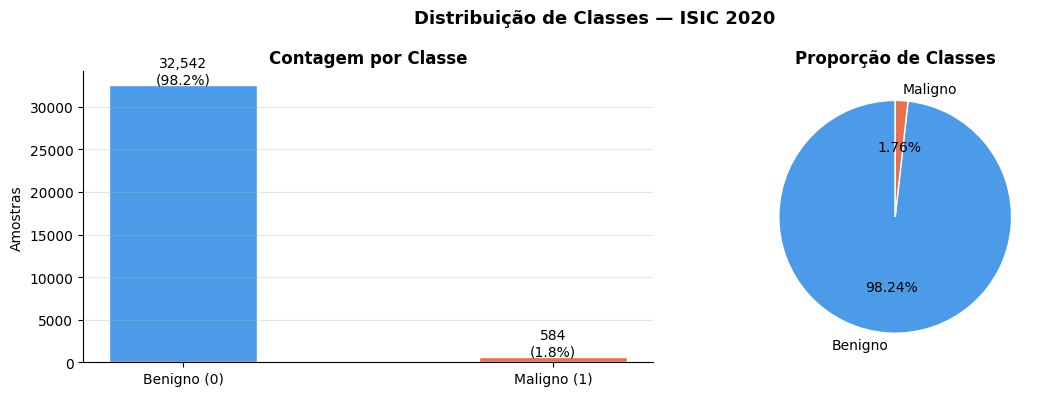

In [11]:
total = len(df)
n_ben = (df['target'] == 0).sum()
n_mal = (df['target'] == 1).sum()
pct_mal = n_mal / total * 100

print('=' * 55)
print('  DISTRIBUIÇÃO DE CLASSES')
print('=' * 55)
print(f'  Total   : {total:,}')
print(f'  Benigno : {n_ben:,}  ({100-pct_mal:.2f}%)')
print(f'  Maligno : {n_mal:,}  ({pct_mal:.2f}%)')
print(f'  Razão B:M = {n_ben//n_mal}:1')
print()
print('⚠️  CARACTERÍSTICA PECULIAR DO DATASET:')
print(f'   Desbalanceamento extremo — apenas {pct_mal:.2f}% de malignos!')
print('   Isso exigirá estratégias específicas no treinamento.')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Barras
bars = axes[0].bar(['Benigno (0)', 'Maligno (1)'], [n_ben, n_mal],
                    color=['#4C9BE8','#E8714C'], edgecolor='white', width=0.4)
for b, v in zip(bars, [n_ben, n_mal]):
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+200,
                 f'{v:,}\n({v/total*100:.1f}%)', ha='center', fontsize=10)
axes[0].set_title('Contagem por Classe', fontweight='bold')
axes[0].set_ylabel('Amostras'); axes[0].grid(axis='y', alpha=0.3)
axes[0].spines[['top','right']].set_visible(False)

# Pizza
axes[1].pie([n_ben, n_mal], labels=['Benigno','Maligno'],
             colors=['#4C9BE8','#E8714C'], autopct='%1.2f%%',
             startangle=90, wedgeprops=dict(edgecolor='white'))
axes[1].set_title('Proporção de Classes', fontweight='bold')

plt.suptitle('Distribuição de Classes — ISIC 2020', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(CFG['output_dir'], '01_classes.png'), dpi=100)
plt.show()


## 1.3 – Features Tabulares por Classe

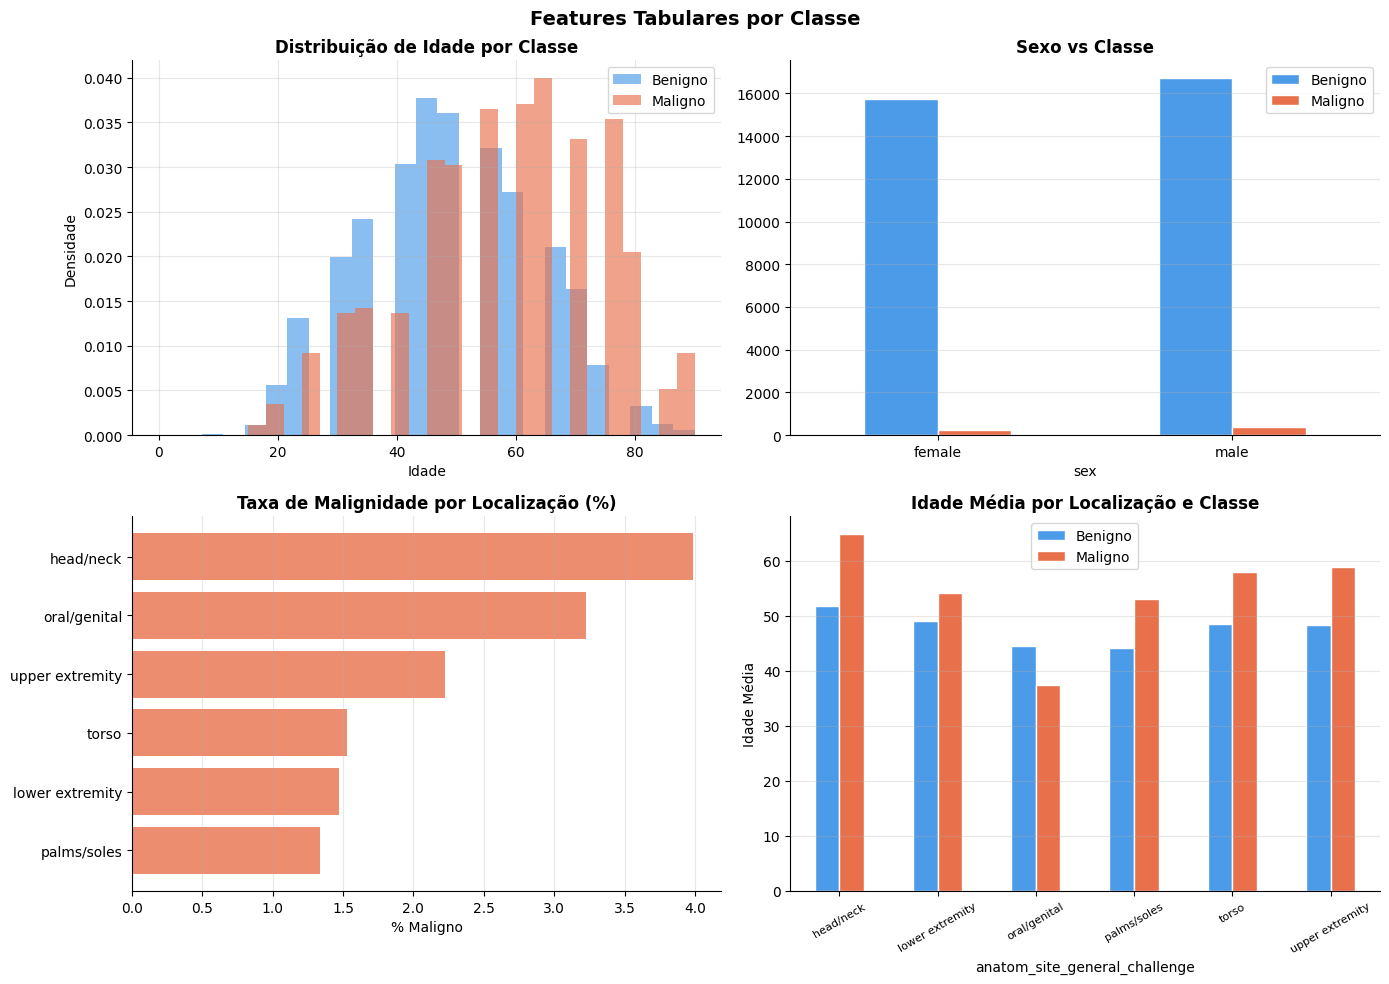


Idade por classe:
  Benigno: média=48.7  mediana=50  std=14.3
  Maligno: média=58.1  mediana=60  std=16.2

Taxa maligno por sexo (%):
sex
female    1.38
male      2.13

Taxa maligno por localização (%):
anatom_site_general_challenge
head/neck          3.99
oral/genital       3.23
upper extremity    2.23
torso              1.53
lower extremity    1.47
palms/soles        1.33


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Features Tabulares por Classe', fontsize=14, fontweight='bold')

# Idade por classe
for cls, lbl, cor in [(0,'Benigno','#4C9BE8'),(1,'Maligno','#E8714C')]:
    axes[0,0].hist(df[df['target']==cls]['age_approx'].dropna(),
                   bins=25, alpha=0.65, color=cor, label=lbl, density=True)
axes[0,0].set_title('Distribuição de Idade por Classe', fontweight='bold')
axes[0,0].set_xlabel('Idade'); axes[0,0].set_ylabel('Densidade')
axes[0,0].legend(); axes[0,0].grid(alpha=0.3)

# Sexo vs classe
df_sex = df.groupby(['sex','target']).size().reset_index(name='n')
df_sex_piv = df_sex.pivot(index='sex', columns='target', values='n').fillna(0)
df_sex_piv.columns = ['Benigno','Maligno']
df_sex_piv.plot(kind='bar', ax=axes[0,1], color=['#4C9BE8','#E8714C'],
                edgecolor='white', rot=0)
axes[0,1].set_title('Sexo vs Classe', fontweight='bold')
axes[0,1].legend(); axes[0,1].grid(axis='y', alpha=0.3)

# Taxa de malignidade por localização
taxa_site = df.groupby('anatom_site_general_challenge')['target'].mean().mul(100).sort_values()
axes[1,0].barh(taxa_site.index, taxa_site.values, color='#E8714C', alpha=0.8)
axes[1,0].set_title('Taxa de Malignidade por Localização (%)', fontweight='bold')
axes[1,0].set_xlabel('% Maligno'); axes[1,0].grid(axis='x', alpha=0.3)

# Idade média por localização e classe
pivot_age = (df.groupby(['anatom_site_general_challenge','target'])
               ['age_approx'].mean().unstack()
               .rename(columns={0:'Benigno',1:'Maligno'}).dropna())
pivot_age.plot(kind='bar', ax=axes[1,1], color=['#4C9BE8','#E8714C'],
               edgecolor='white', rot=30)
axes[1,1].set_title('Idade Média por Localização e Classe', fontweight='bold')
axes[1,1].set_ylabel('Idade Média'); axes[1,1].legend(); axes[1,1].grid(axis='y', alpha=0.3)
axes[1,1].tick_params(axis='x', labelsize=8)

for ax in axes.flatten(): ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(CFG['output_dir'], '02_features_tabulares.png'), dpi=100)
plt.show()

# Estatísticas textuais
print('\nIdade por classe:')
for cls, lbl in [(0,'Benigno'),(1,'Maligno')]:
    ages = df[df['target']==cls]['age_approx'].dropna()
    print(f'  {lbl}: média={ages.mean():.1f}  mediana={ages.median():.0f}  std={ages.std():.1f}')
print('\nTaxa maligno por sexo (%):')
print(df.groupby('sex')['target'].mean().mul(100).round(2).to_string())
print('\nTaxa maligno por localização (%):')
print(df.groupby('anatom_site_general_challenge')['target'].mean().mul(100).round(2)
        .sort_values(ascending=False).to_string())


## 1.4 – Valores Ausentes e Distribuição de Diagnósticos

Valores ausentes:
                               count   pct
sex                               65  0.20
age_approx                        68  0.21
anatom_site_general_challenge    527  1.59


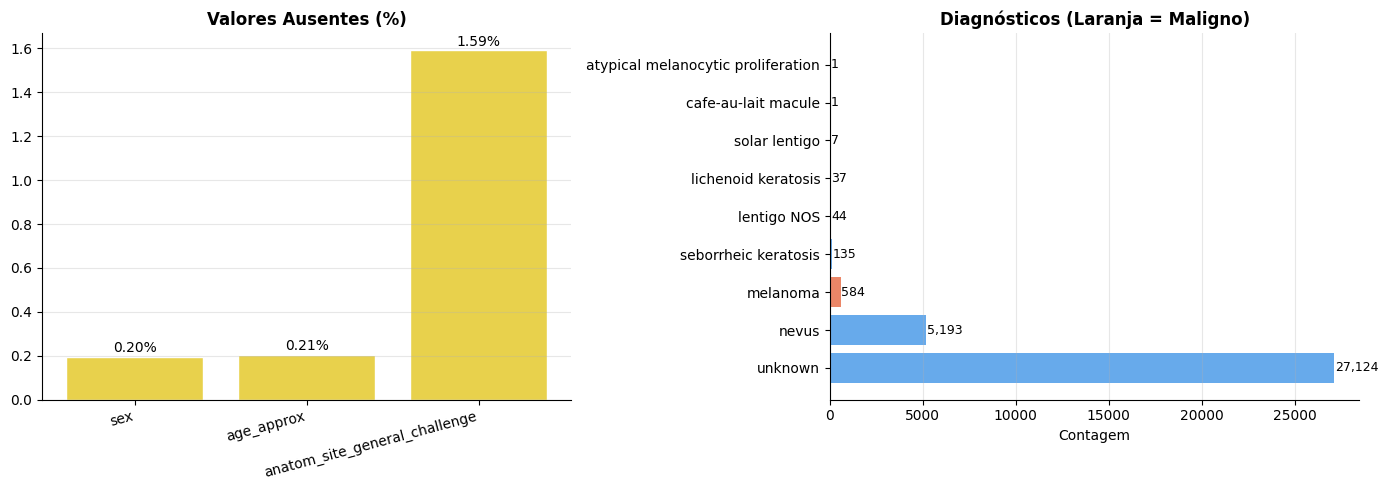

In [13]:
nulos = df.isnull().sum()
print('Valores ausentes:')
print(nulos[nulos > 0].to_frame('count')
        .assign(pct=lambda x: (x['count']/len(df)*100).round(2)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Nulos
nulos_pct = nulos[nulos > 0] / len(df) * 100
axes[0].bar(nulos_pct.index, nulos_pct.values, color='#E8D14C', edgecolor='white')
for i,(col,v) in enumerate(nulos_pct.items()):
    axes[0].text(i, v+0.02, f'{v:.2f}%', ha='center', fontsize=10)
axes[0].set_title('Valores Ausentes (%)', fontweight='bold')
axes[0].set_xticklabels(nulos_pct.index, rotation=15, ha='right')
axes[0].grid(axis='y', alpha=0.3)
axes[0].spines[['top','right']].set_visible(False)

# Diagnósticos
diag_counts = df['diagnosis'].value_counts()
cores_diag = ['#E8714C' if d=='melanoma' else '#4C9BE8' for d in diag_counts.index]
axes[1].barh(diag_counts.index, diag_counts.values, color=cores_diag, alpha=0.85)
for i,(_, v) in enumerate(diag_counts.items()):
    axes[1].text(v+30, i, f'{v:,}', va='center', fontsize=9)
axes[1].set_title('Diagnósticos (Laranja = Maligno)', fontweight='bold')
axes[1].set_xlabel('Contagem'); axes[1].grid(axis='x', alpha=0.3)
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(CFG['output_dir'], '03_nulos_diagnosticos.png'), dpi=100)
plt.show()


## 1.5 – Análise de Pacientes (Risco de Data Leakage)
> **Esta é uma das características mais importantes do dataset!**
> Como um mesmo paciente pode ter múltiplas imagens, um split aleatório
> colocaria imagens do mesmo paciente em treino e teste — **data leakage**.


  ANÁLISE DE PACIENTES
  Pacientes únicos       : 2,056
  Imagens/paciente (min) : 2
  Imagens/paciente (max) : 115
  Imagens/paciente (med) : 16.1
  Pacientes c/ malignos  : 428

⚠️  DECISÃO: usar GroupShuffleSplit por patient_id
   Garante que nenhum paciente apareça em dois conjuntos.


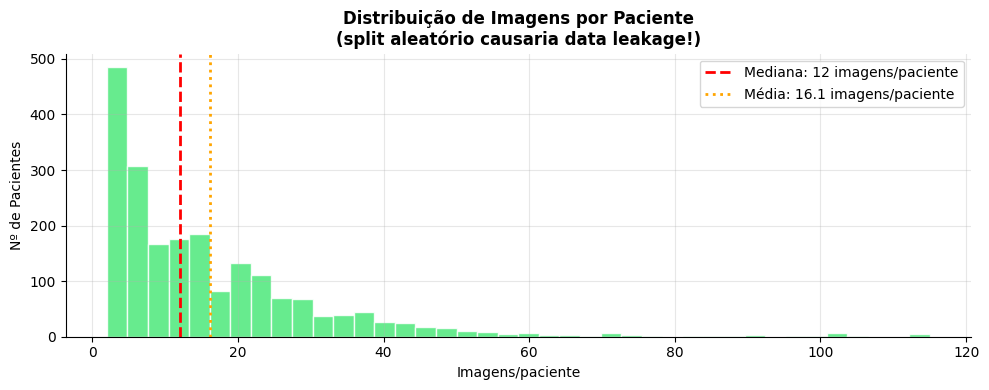

In [14]:
n_pac = df['patient_id'].nunique()
img_pp = df.groupby('patient_id').size()
pac_com_mal = df[df['target']==1]['patient_id'].nunique()

print('=' * 55)
print('  ANÁLISE DE PACIENTES')
print('=' * 55)
print(f'  Pacientes únicos       : {n_pac:,}')
print(f'  Imagens/paciente (min) : {img_pp.min()}')
print(f'  Imagens/paciente (max) : {img_pp.max()}')
print(f'  Imagens/paciente (med) : {img_pp.mean():.1f}')
print(f'  Pacientes c/ malignos  : {pac_com_mal}')
print()
print('⚠️  DECISÃO: usar GroupShuffleSplit por patient_id')
print('   Garante que nenhum paciente apareça em dois conjuntos.')

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(img_pp.values, bins=40, color='#4CE87A', edgecolor='white', alpha=0.85)
ax.axvline(img_pp.median(), color='red', ls='--', lw=2,
            label=f'Mediana: {img_pp.median():.0f} imagens/paciente')
ax.axvline(img_pp.mean(), color='orange', ls=':', lw=2,
            label=f'Média: {img_pp.mean():.1f} imagens/paciente')
ax.set_title('Distribuição de Imagens por Paciente\n'
              '(split aleatório causaria data leakage!)', fontweight='bold')
ax.set_xlabel('Imagens/paciente'); ax.set_ylabel('Nº de Pacientes')
ax.legend(); ax.grid(alpha=0.3)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(CFG['output_dir'], '04_pacientes.png'), dpi=100)
plt.show()


## 1.6 – Inspeção Visual das Imagens por Classe

Carregando amostras de imagens...


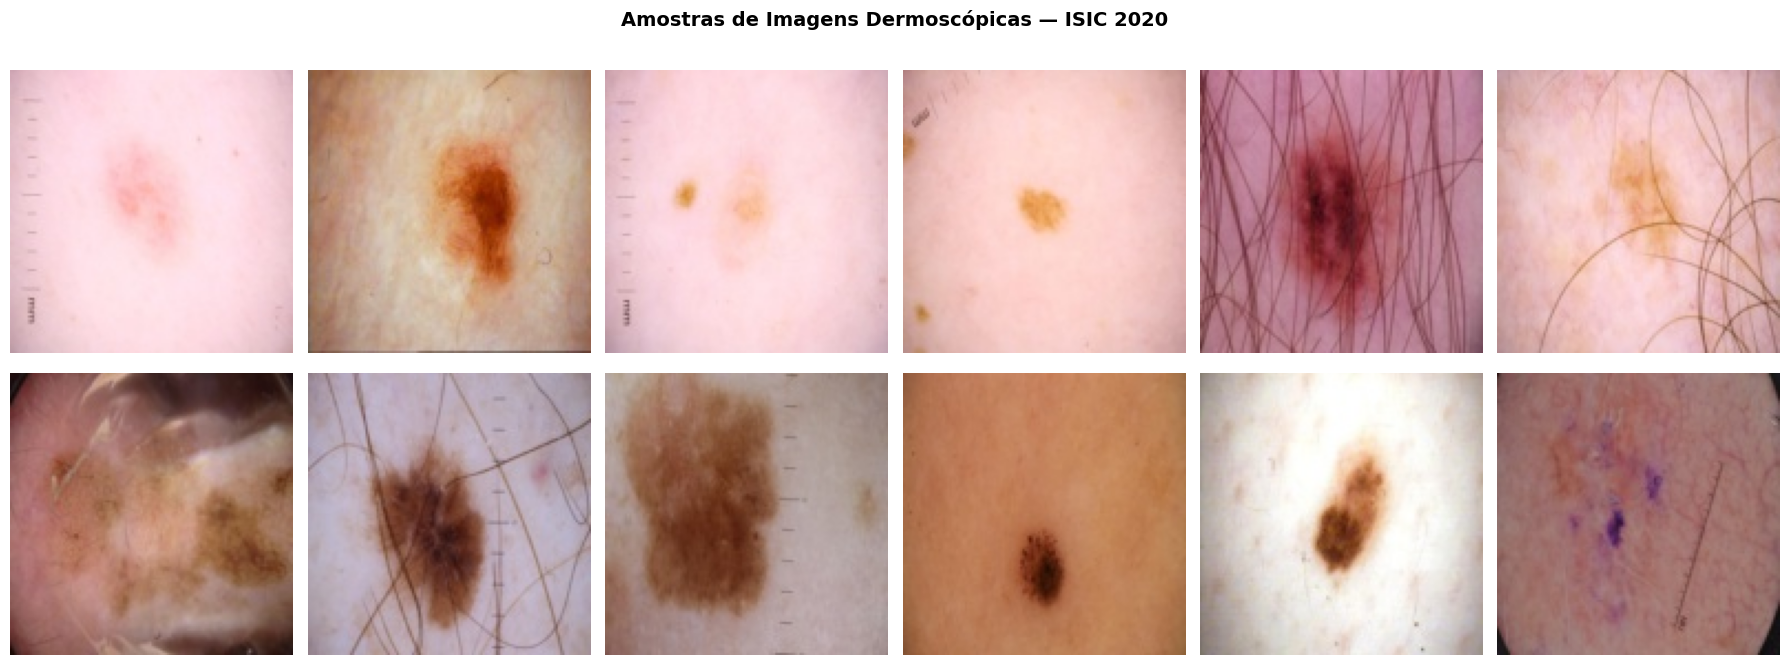

In [15]:
print('Carregando amostras de imagens...')
amostras_ben = df[df['target']==0]['image_name'].sample(6, random_state=42).tolist()
amostras_mal = df[df['target']==1]['image_name'].sample(6, random_state=42).tolist()

fig, axes = plt.subplots(2, 6, figsize=(18, 7))
fig.suptitle('Amostras de Imagens Dermoscópicas — ISIC 2020',
              fontsize=14, fontweight='bold')

with zipfile.ZipFile(CFG['zip_path'], 'r') as zf:
    for row_axes, names, lbl, cor in [
        (axes[0], amostras_ben, 'BENIGNO (0)', '#4C9BE8'),
        (axes[1], amostras_mal, 'MALIGNO (1)', '#E8714C'),
    ]:
        for j, img_name in enumerate(names):
            with zf.open(f'images/{img_name}.jpg') as fp:
                img = Image.open(io.BytesIO(fp.read())).convert('RGB')
            row_axes[j].imshow(img)
            row_axes[j].axis('off')
            if j == 0:
                row_axes[j].set_ylabel(lbl, fontsize=11,
                                        fontweight='bold', color=cor, labelpad=12)

plt.tight_layout()
plt.savefig(os.path.join(CFG['output_dir'], '05_amostras_imagens.png'), dpi=100)
plt.show()


## 1.7 – Estatísticas dos Pixels (Decisão de Normalização)
> Verifica dimensões, distribuição RGB e textura (std) por classe.


Analisando pixels (200 imagens amostrais)...

Dimensão: 128×128 px  (uniforme: True)

Médias dos canais RGB:
  R            média=190.8  std=32.9
  G            média=148.1  std=36.6
  B            média=138.5  std=40.4
  std_total    média=38.0  std=11.6

✓ DECISÕES:
  • Imagens 128×128 → upscale para 224 (padrão ImageNet)
  • Normalização com médias/stds ImageNet (backbones pré-treinados)
  • Augmentação agressiva para malignos (classe minoritária)


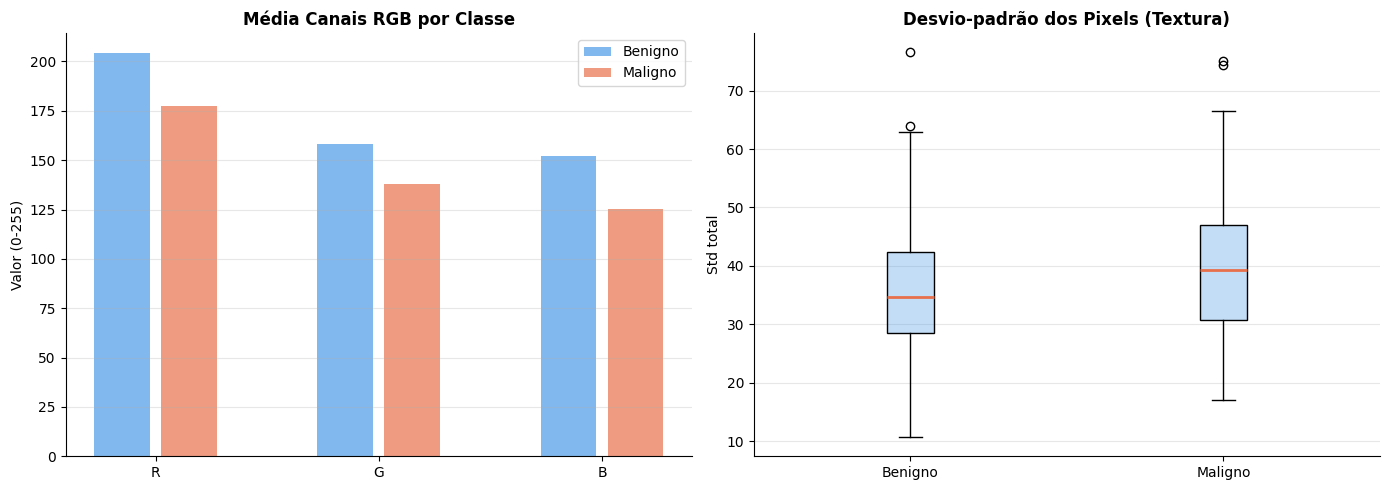

In [16]:
print('Analisando pixels (200 imagens amostrais)...')
pixel_stats = {'R':[],'G':[],'B':[],'std_total':[],'classe':[],'w':[],'h':[]}

sample_ids = (
    df[df['target']==0]['image_name'].sample(100, random_state=42).tolist() +
    df[df['target']==1]['image_name'].sample(100, random_state=42).tolist()
)
labels_px = [0]*100 + [1]*100

with zipfile.ZipFile(CFG['zip_path'], 'r') as zf:
    for img_name, lbl in zip(sample_ids, labels_px):
        with zf.open(f'images/{img_name}.jpg') as fp:
            img = Image.open(io.BytesIO(fp.read())).convert('RGB')
            arr = np.array(img).astype(float)
        pixel_stats['R'].append(arr[:,:,0].mean())
        pixel_stats['G'].append(arr[:,:,1].mean())
        pixel_stats['B'].append(arr[:,:,2].mean())
        pixel_stats['std_total'].append(arr.std())
        pixel_stats['classe'].append('Benigno' if lbl==0 else 'Maligno')
        pixel_stats['w'].append(img.size[0])
        pixel_stats['h'].append(img.size[1])

df_px = pd.DataFrame(pixel_stats)

print(f'\nDimensão: {df_px["w"].iloc[0]}×{df_px["h"].iloc[0]} px  '
      f'(uniforme: {df_px["w"].nunique()==1})')
print('\nMédias dos canais RGB:')
for canal in ['R','G','B','std_total']:
    print(f'  {canal:<12} média={df_px[canal].mean():.1f}  std={df_px[canal].std():.1f}')

print('\n✓ DECISÕES:')
print('  • Imagens 128×128 → upscale para 224 (padrão ImageNet)')
print('  • Normalização com médias/stds ImageNet (backbones pré-treinados)')
print('  • Augmentação agressiva para malignos (classe minoritária)')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Médias RGB
x = ['R-Ben','G-Ben','B-Ben','R-Mal','G-Mal','B-Mal']
ben = df_px[df_px['classe']=='Benigno']
mal = df_px[df_px['classe']=='Maligno']
axes[0].bar(['R','G','B'], [ben['R'].mean(),ben['G'].mean(),ben['B'].mean()],
             alpha=0.7, color='#4C9BE8', label='Benigno', width=0.25)
axes[0].bar([0.3,1.3,2.3], [mal['R'].mean(),mal['G'].mean(),mal['B'].mean()],
             alpha=0.7, color='#E8714C', label='Maligno', width=0.25)
axes[0].set_title('Média Canais RGB por Classe', fontweight='bold')
axes[0].set_ylabel('Valor (0-255)'); axes[0].legend()
axes[0].set_xticks([0.15,1.15,2.15]); axes[0].set_xticklabels(['R','G','B'])
axes[0].grid(axis='y', alpha=0.3)

# Boxplot std por classe
axes[1].boxplot(
    [ben['std_total'].values, mal['std_total'].values],
    labels=['Benigno','Maligno'], patch_artist=True,
    boxprops=dict(facecolor='#4C9BE855'),
    medianprops=dict(color='#E8714C', linewidth=2),
)
axes[1].set_title('Desvio-padrão dos Pixels (Textura)', fontweight='bold')
axes[1].set_ylabel('Std total'); axes[1].grid(axis='y', alpha=0.3)

for ax in axes: ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(CFG['output_dir'], '06_pixel_stats.png'), dpi=100)
plt.show()


---
# 🔧 PARTE 2 — Pré-processamento
Todas as decisões abaixo são **justificadas pela EDA** realizada acima.


## 2.1 – Pré-processamento Tabular
| Feature | Problema | Decisão |
|---|---|---|
| `sex` | 65 nulos (0.2%) | Moda (`male`) |
| `age_approx` | 68 nulos (0.2%) | Mediana (distribuição levemente assimétrica) |
| `anatom_site` | 527 nulos (1.6%) | `'unknown'` (não é desprezível) |
| Categóricas | Nominais, baixa cardinalidade | `LabelEncoder` |
| `age_approx` | Escala contínua | `StandardScaler` |


In [17]:
def preprocessar_tabular(df):
    df = df.copy()
    # Imputação
    df['sex'] = df['sex'].fillna(df['sex'].mode()[0])
    df['age_approx'] = df['age_approx'].fillna(df['age_approx'].median())
    df['anatom_site_general_challenge'] = \
        df['anatom_site_general_challenge'].fillna('unknown')

    # Encoding e normalização
    le_sex  = LabelEncoder().fit(df['sex'])
    le_site = LabelEncoder().fit(df['anatom_site_general_challenge'])
    scaler  = StandardScaler().fit(df[['age_approx']])

    df['sex_enc']  = le_sex.transform(df['sex'])
    df['site_enc'] = le_site.transform(df['anatom_site_general_challenge'])
    df['age_norm'] = scaler.transform(df[['age_approx']])

    TAB_COLS = ['age_norm', 'sex_enc', 'site_enc']
    return df, TAB_COLS, scaler, le_sex, le_site

df, TAB_COLS, scaler, le_sex, le_site = preprocessar_tabular(df)
print(f'Features tabulares: {TAB_COLS}')
print(f'sex  → {list(le_sex.classes_)}')
print(f'site → {list(le_site.classes_)}')
print(f'\nAmostra pós-processamento:')
df[TAB_COLS + ['target']].head()


Features tabulares: ['age_norm', 'sex_enc', 'site_enc']
sex  → ['female', 'male']
site → ['head/neck', 'lower extremity', 'oral/genital', 'palms/soles', 'torso', 'unknown', 'upper extremity']

Amostra pós-processamento:


,age_norm,sex_enc,site_enc,target
0,-0.269559,1,0,0
1,-0.269559,0,6,0
2,0.078498,0,1,0
3,-0.269559,0,0,0
4,0.426555,0,6,0


## 2.2 – Split por Paciente (Anti Data Leakage)
> `GroupShuffleSplit` garante que **nenhum paciente** apareça em mais de um conjunto.


In [18]:
def split_por_paciente(df, test_size=0.15, val_size=0.15, seed=42):
    gss_test = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=seed)
    idx_all  = np.arange(len(df))
    tr_val, ts = next(gss_test.split(idx_all, df['target'].values,
                                      groups=df['patient_id'].values))
    df_tv   = df.iloc[tr_val].reset_index(drop=True)
    df_test = df.iloc[ts].reset_index(drop=True)

    vf = val_size / (1 - test_size)
    gss_val = GroupShuffleSplit(n_splits=1, test_size=vf, random_state=seed)
    tr, vl  = next(gss_val.split(np.arange(len(df_tv)), df_tv['target'].values,
                                  groups=df_tv['patient_id'].values))
    df_train = df_tv.iloc[tr].reset_index(drop=True)
    df_val   = df_tv.iloc[vl].reset_index(drop=True)

    # Verificação anti-leakage
    assert len(set(df_train['patient_id']) & set(df_test['patient_id'])) == 0
    assert len(set(df_val['patient_id'])   & set(df_test['patient_id'])) == 0

    print(f'Treino : {len(df_train):,}  ({df_train["target"].mean()*100:.2f}% malignos)')
    print(f'Val    : {len(df_val):,}  ({df_val["target"].mean()*100:.2f}% malignos)')
    print(f'Teste  : {len(df_test):,}  ({df_test["target"].mean()*100:.2f}% malignos)')
    print('Anti-leakage: OK ✓')
    return df_train, df_val, df_test

df_train, df_val, df_test = split_por_paciente(df)
n_tab = len(TAB_COLS)
print(f'\nFeatures por amostra: {n_tab} tabulares + 1 imagem (224×224×3)')


Treino : 23,257  (1.84% malignos)
Val    : 4,835  (1.45% malignos)
Teste  : 5,034  (1.73% malignos)
Anti-leakage: OK ✓

Features por amostra: 3 tabulares + 1 imagem (224×224×3)


## 2.3 – Dataset PyTorch e DataLoaders
**Transformações de treino** (augmentação agressiva para malignos):
- Flip horizontal/vertical, rotação ±30°, ColorJitter, RandomAffine

**Estratégia anti-desbalanceamento**:
1. `WeightedRandomSampler` — equilibra classes nos batches
2. `BCEWithLogitsLoss(pos_weight=10)` — penaliza mais falsos negativos
3. Threshold=0.30 — mais sensível a malignos


In [19]:
IMAGENET_NORM = transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])

TRAIN_TF = transforms.Compose([
    transforms.Resize((CFG['img_size'], CFG['img_size'])),  # 128 → 224
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomVerticalFlip(0.3),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
    transforms.RandomAffine(degrees=0, translate=(0.1,0.1), scale=(0.9,1.1)),
    transforms.ToTensor(),
    IMAGENET_NORM,
])
VAL_TF = transforms.Compose([
    transforms.Resize((CFG['img_size'], CFG['img_size'])),
    transforms.ToTensor(),
    IMAGENET_NORM,
])

class ISICDataset(Dataset):
    def __init__(self, df, zip_path, tab_cols, mode='train'):
        self.df = df.reset_index(drop=True)
        self.zip_path = zip_path
        self.tab_cols = tab_cols
        self.tf = TRAIN_TF if mode == 'train' else VAL_TF
        self._zf = None

    def _get_zf(self):
        if self._zf is None:
            self._zf = zipfile.ZipFile(self.zip_path, 'r')
        return self._zf

    def __len__(self):
        return len(self.df)

    def __getitem__(self, i):
        row = self.df.iloc[i]
        try:
            with self._get_zf().open(f'images/{row["image_name"]}.jpg') as fp:
                img = Image.open(io.BytesIO(fp.read())).convert('RGB')
        except Exception:
            img = Image.new('RGB', (CFG['img_size'], CFG['img_size']))
        img_t = self.tf(img)
        tab_t = torch.tensor(row[self.tab_cols].values.astype(np.float32))
        lbl   = torch.tensor(float(row['target']))
        return img_t, tab_t, lbl

    def __del__(self):
        if self._zf: self._zf.close()

def criar_loaders(df_tr, df_vl, df_ts, zip_path, tab_cols):
    ds_tr = ISICDataset(df_tr, zip_path, tab_cols, 'train')
    ds_vl = ISICDataset(df_vl, zip_path, tab_cols, 'val')
    ds_ts = ISICDataset(df_ts, zip_path, tab_cols, 'test')
    cnts  = df_tr['target'].value_counts()
    w     = df_tr['target'].map({c: 1.0/cnts[c] for c in cnts.index}).values
    sampler = WeightedRandomSampler(torch.DoubleTensor(w), len(w), replacement=True)
    kw = dict(num_workers=CFG['num_workers'], pin_memory=(DEVICE.type=='cuda'))
    dl_tr = DataLoader(ds_tr, CFG['batch_size'], sampler=sampler, **kw)
    dl_vl = DataLoader(ds_vl, CFG['batch_size']*2, shuffle=False, **kw)
    dl_ts = DataLoader(ds_ts, CFG['batch_size']*2, shuffle=False, **kw)
    return dl_tr, dl_vl, dl_ts

dl_tr, dl_vl, dl_ts = criar_loaders(df_train, df_val, df_test, CFG['zip_path'], TAB_COLS)
print(f'DataLoaders criados:')
print(f'  Treino  : {len(dl_tr):,} batches')
print(f'  Val     : {len(dl_vl):,} batches')
print(f'  Teste   : {len(dl_ts):,} batches')


DataLoaders criados:
  Treino  : 727 batches
  Val     : 76 batches
  Teste   : 79 batches


---
# 🧠 PARTE 3 — Arquiteturas Multimodais
Estrutura geral de todas as arquiteturas:
```
Imagem (224×224)  → [Backbone CNN] → 512 features ─┐
                                                      ├── Cat → [FC 256→64→1] → P(Maligno)
Tabular (3 feat.) → [MLP 3→128→64] → 64 features ──┘
```


## 3.1 – Módulos Compartilhados (BlocoTabular + CabecaFusao)

In [20]:
class BlocoTabular(nn.Module):
    """MLP para processar features clínicas: age, sex, site."""
    def __init__(self, n_in=3, hidden=(128,64), drop=0.4):
        super().__init__()
        layers, d = [], n_in
        for h in hidden:
            layers += [nn.Linear(d,h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(drop)]
            d = h
        self.net = nn.Sequential(*layers)
        self.out_dim = d
    def forward(self, x): return self.net(x)


class CabecaFusao(nn.Module):
    """Cabeça de fusão: concatena features de imagem e tabulares → logit."""
    def __init__(self, in_dim, hidden=(256,64), drop=0.4):
        super().__init__()
        layers, d = [], in_dim
        for h in hidden:
            layers += [nn.Linear(d,h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(drop)]
            d = h
        layers.append(nn.Linear(d, 1))
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x).squeeze(1)


print('Módulos compartilhados definidos ✓')


Módulos compartilhados definidos ✓


## 3.2 – Arquitetura ① EfficientNet-B0
> **Escolha:** melhor trade-off parâmetros × performance em benchmarks de pele. ~4,8M params.


In [21]:
class ModeloEfficientNetB0(nn.Module):
    NOME = 'EfficientNet-B0'
    COR  = '#4C9BE8'

    def __init__(self, n_tab=3):
        super().__init__()
        bb = efficientnet_b0(weights=None)
        in_f = bb.classifier[1].in_features  # 1280
        bb.classifier = nn.Sequential(
            nn.Dropout(CFG['dropout']),
            nn.Linear(in_f, 512), nn.ReLU(),
        )
        self.img  = bb
        self.tab  = BlocoTabular(n_tab)
        self.head = CabecaFusao(512 + self.tab.out_dim)

    def forward(self, img, tab):
        return self.head(torch.cat([self.img(img), self.tab(tab)], dim=1))


m = ModeloEfficientNetB0(n_tab).to(DEVICE)
p = sum(x.numel() for x in m.parameters() if x.requires_grad)
print(f'EfficientNet-B0: {p:,} parâmetros')


EfficientNet-B0: 4,837,437 parâmetros


## 3.3 – Arquitetura ② ResNet-50
> **Escolha:** backbone clássico com conexões residuais, referência consolidada em imagem médica. ~24,7M params.


In [22]:
class ModeloResNet50(nn.Module):
    NOME = 'ResNet-50'
    COR  = '#E8714C'

    def __init__(self, n_tab=3):
        super().__init__()
        bb = resnet50(weights=None)
        in_f = bb.fc.in_features  # 2048
        bb.fc = nn.Sequential(
            nn.Dropout(CFG['dropout']),
            nn.Linear(in_f, 512), nn.ReLU(),
        )
        self.img  = bb
        self.tab  = BlocoTabular(n_tab)
        self.head = CabecaFusao(512 + self.tab.out_dim)

    def forward(self, img, tab):
        return self.head(torch.cat([self.img(img), self.tab(tab)], dim=1))


m = ModeloResNet50(n_tab).to(DEVICE)
p = sum(x.numel() for x in m.parameters() if x.requires_grad)
print(f'ResNet-50: {p:,} parâmetros')


ResNet-50: 24,731,137 parâmetros


## 3.4 – Arquitetura ③ MobileNetV3-Large
> **Escolha:** o mais leve dos três, ideal para deploy em borda. Usa Hardswish + Squeeze-and-Excite. ~3,9M params.


In [23]:
class ModeloMobileNetV3(nn.Module):
    NOME = 'MobileNetV3-L'
    COR  = '#4CE87A'

    def __init__(self, n_tab=3):
        super().__init__()
        bb = mobilenet_v3_large(weights=None)
        in_f = bb.classifier[0].in_features  # 960
        bb.classifier = nn.Sequential(
            nn.Linear(in_f, 512), nn.Hardswish(),
            nn.Dropout(CFG['dropout']),
            nn.Linear(512, 512), nn.ReLU(),
        )
        self.img  = bb
        self.tab  = BlocoTabular(n_tab)
        self.head = CabecaFusao(512 + self.tab.out_dim)

    def forward(self, img, tab):
        return self.head(torch.cat([self.img(img), self.tab(tab)], dim=1))


m = ModeloMobileNetV3(n_tab).to(DEVICE)
p = sum(x.numel() for x in m.parameters() if x.requires_grad)
print(f'MobileNetV3-L: {p:,} parâmetros')


MobileNetV3-L: 3,900,657 parâmetros


## 3.5 – Baseline ④ Tabular-MLP (sem imagem)
> Permite quantificar o **ganho real** trazido pela modalidade visual.


In [24]:
class ModeloTabularBaseline(nn.Module):
    NOME = 'Tabular-MLP'
    COR  = '#E8D14C'

    def __init__(self, n_tab=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_tab, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256,   128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128,    64), nn.BatchNorm1d(64),  nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64,      1),
        )

    def forward(self, img, tab):  # img ignorada
        return self.net(tab).squeeze(1)


ARQUITETURAS = [ModeloEfficientNetB0, ModeloResNet50,
                ModeloMobileNetV3,    ModeloTabularBaseline]

print('Arquiteturas registradas:')
for Cls in ARQUITETURAS:
    m = Cls(n_tab).to(DEVICE)
    p = sum(x.numel() for x in m.parameters() if x.requires_grad)
    print(f'  {Cls.NOME:<22} {p:>12,} parâmetros')
    del m


Arquiteturas registradas:
  EfficientNet-B0           4,837,437 parâmetros
  ResNet-50                24,731,137 parâmetros
  MobileNetV3-L             3,900,657 parâmetros
  Tabular-MLP                  43,137 parâmetros


---
# 🏋️ PARTE 4 — Treinamento e Avaliação


## 4.1 – Funções de Treinamento e Avaliação

In [25]:
def _epoch_train(model, dl, opt, crit):
    model.train()
    loss_tot, probs_, labels_ = 0.0, [], []
    for imgs, tabs, lbls in dl:
        imgs, tabs, lbls = imgs.to(DEVICE), tabs.to(DEVICE), lbls.to(DEVICE)
        opt.zero_grad()
        logits = model(imgs, tabs)
        loss   = crit(logits, lbls)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        loss_tot += loss.item() * len(lbls)
        probs_.extend(torch.sigmoid(logits).detach().cpu().numpy())
        labels_.extend(lbls.cpu().numpy())
    n   = len(labels_)
    auc = roc_auc_score(labels_, probs_) if len(set(labels_)) > 1 else 0.0
    return loss_tot / n, auc


@torch.no_grad()
def _epoch_eval(model, dl, crit):
    model.eval()
    loss_tot, probs_, labels_ = 0.0, [], []
    for imgs, tabs, lbls in dl:
        imgs, tabs, lbls = imgs.to(DEVICE), tabs.to(DEVICE), lbls.to(DEVICE)
        logits = model(imgs, tabs)
        loss_tot += crit(logits, lbls).item() * len(lbls)
        probs_.extend(torch.sigmoid(logits).cpu().numpy())
        labels_.extend(lbls.cpu().numpy())
    n   = len(labels_)
    auc = roc_auc_score(labels_, probs_) if len(set(labels_)) > 1 else 0.0
    return loss_tot / n, auc, np.array(labels_), np.array(probs_)


def treinar(Cls, dl_tr, dl_vl, n_tab):
    model   = Cls(n_tab).to(DEVICE)
    nparams = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\n{'─'*60}")
    print(f"  {Cls.NOME:<22}  {nparams:,} parâmetros")
    print(f"{'─'*60}")
    pw    = torch.tensor([CFG['pos_weight']], device=DEVICE)
    crit  = nn.BCEWithLogitsLoss(pos_weight=pw)
    opt   = torch.optim.AdamW(model.parameters(), lr=CFG['lr'],
                               weight_decay=CFG['weight_decay'])
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(
        opt, T_max=CFG['epochs'], eta_min=1e-6)
    hist = dict(tr_loss=[], vl_loss=[], tr_auc=[], vl_auc=[])
    best_auc, best_state, t0 = 0.0, None, time.time()
    for ep in range(1, CFG['epochs']+1):
        trl, tra = _epoch_train(model, dl_tr, opt, crit)
        vll, vla, _, _ = _epoch_eval(model, dl_vl, crit)
        sched.step()
        hist['tr_loss'].append(trl); hist['vl_loss'].append(vll)
        hist['tr_auc'].append(tra);  hist['vl_auc'].append(vla)
        flag = ''
        if vla > best_auc:
            best_auc = vla; best_state = deepcopy(model.state_dict()); flag = '  ★'
        print(f"  Ep {ep:3d}/{CFG['epochs']}  "
              f"Loss[tr={trl:.4f} vl={vll:.4f}]  "
              f"AUC[tr={tra:.4f} vl={vla:.4f}]{flag}")
    tempo = time.time() - t0
    model.load_state_dict(best_state)
    print(f"  Concluído em {tempo:.1f}s  |  Melhor AUC-val: {best_auc:.4f}")
    return model, hist, nparams, tempo

print('Funções de treinamento definidas ✓')


Funções de treinamento definidas ✓


## 4.2 – Função de Métricas (13 métricas)

In [26]:
def calcular_metricas(labels, probs, thr, nome):
    """Calcula 13 métricas para benigno=0 / maligno=1."""
    preds = (probs >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(labels, preds).ravel()

    # Threshold ótimo de Youden (J = Sensib + Especif − 1)
    fpr_, tpr_, thrs_ = roc_curve(labels, probs)
    thr_opt = float(thrs_[np.argmax(tpr_ - fpr_)])
    p_opt   = (probs >= thr_opt).astype(int)
    tn2, fp2, fn2, tp2 = confusion_matrix(labels, p_opt).ravel()

    return {
        'Modelo':          nome,
        'AUC-ROC':         round(roc_auc_score(labels, probs), 4),
        'PR-AUC':          round(average_precision_score(labels, probs), 4),
        'Accuracy':        round(accuracy_score(labels, preds), 4),
        'Balanced Acc':    round(balanced_accuracy_score(labels, preds), 4),
        'Precisão':        round(precision_score(labels, preds, zero_division=0), 4),
        'Recall/Sensib.':  round(recall_score(labels, preds, zero_division=0), 4),
        'Especificidade':  round(tn/(tn+fp) if (tn+fp)>0 else 0.0, 4),
        'F1-Score':        round(f1_score(labels, preds, zero_division=0), 4),
        'MCC':             round(matthews_corrcoef(labels, preds), 4),
        'Brier Score':     round(brier_score_loss(labels, probs), 4),
        'Log-Loss':        round(log_loss(labels, probs), 4),
        'Thr (fixo)':      round(thr, 3),
        'Thr ótimo':       round(thr_opt, 3),
        'Sens@Thr-ótimo':  round(tp2/(tp2+fn2) if (tp2+fn2)>0 else 0, 4),
        'Spec@Thr-ótimo':  round(tn2/(tn2+fp2) if (tn2+fp2)>0 else 0, 4),
        'TP': int(tp), 'FP': int(fp), 'TN': int(tn), 'FN': int(fn),
    }

print('Função de métricas definida ✓')


Função de métricas definida ✓


## 4.3 – Treinamento das 4 Arquiteturas
> ⏱️ Esta célula pode levar de **15 min a 2 horas** dependendo da GPU e número de épocas.
> Com GPU T4 (Colab gratuito) e 15 épocas: ~30–45 min.


In [28]:
pw   = torch.tensor([CFG['pos_weight']], device=DEVICE)
crit = nn.BCEWithLogitsLoss(pos_weight=pw)

hists, resultados = {}, {}

for Cls in ARQUITETURAS:
    seed_all()
    model, hist, npar, tempo = treinar(Cls, dl_tr, dl_vl, n_tab)

    _, _, labels_ts, probs_ts = _epoch_eval(model, dl_ts, crit)
    m = calcular_metricas(labels_ts, probs_ts, CFG['threshold'], Cls.NOME)
    m['Parâmetros'] = f'{npar:,}'
    m['Tempo (s)']  = f'{tempo:.1f}'

    hists[Cls.NOME]      = hist
    resultados[Cls.NOME] = {'labels': labels_ts, 'probs': probs_ts, 'm': m}

    # Salva checkpoint
    torch.save(model.state_dict(),
               os.path.join(CFG['output_dir'], f'modelo_{Cls.NOME}.pth'))

    print(f"\n  ► TESTE — AUC:{m['AUC-ROC']}  "
          f"Sens:{m['Recall/Sensib.']}  "
          f"Spec:{m['Especificidade']}  "
          f"F1:{m['F1-Score']}")

df_m = pd.DataFrame([r['m'] for r in resultados.values()])
df_m.to_csv(os.path.join(CFG['output_dir'], 'metricas.csv'), index=False)
print('\nTreinamento concluído ✓  |  metricas.csv salvo')



────────────────────────────────────────────────────────────
  EfficientNet-B0         4,837,437 parâmetros
────────────────────────────────────────────────────────────
  Ep   1/15  Loss[tr=2.1857 vl=1.4264]  AUC[tr=0.6837 vl=0.7493]  ★
  Ep   2/15  Loss[tr=1.5099 vl=1.5544]  AUC[tr=0.7519 vl=0.7959]  ★
  Ep   3/15  Loss[tr=1.4400 vl=1.7321]  AUC[tr=0.7718 vl=0.7843]
  Ep   4/15  Loss[tr=1.3698 vl=1.7408]  AUC[tr=0.7909 vl=0.8231]  ★


KeyboardInterrupt: 

---
# 📈 PARTE 5 — Visualizações e Comparação


## 5.1 – Histórico de Treinamento

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(22, 9))
fig.suptitle('Histórico de Treinamento', fontsize=14, fontweight='bold')
eps = range(1, CFG['epochs']+1)

for col, (nome, hist) in enumerate(hists.items()):
    cor = ARQUITETURAS[col].COR
    for row, (tk, vk, ylabel) in enumerate([
        ('tr_loss','vl_loss','BCE Loss'),
        ('tr_auc', 'vl_auc', 'AUC-ROC'),
    ]):
        ax = axes[row][col]
        ax.plot(eps, hist[tk], '--', color=cor, alpha=0.6, label='Treino')
        ax.plot(eps, hist[vk],       color=cor, lw=2,     label='Validação')
        ax.set_title(f'{nome} — {ylabel}', fontweight='bold', fontsize=10)
        ax.set_xlabel('Época'); ax.set_ylabel(ylabel)
        ax.legend(fontsize=8); ax.grid(alpha=0.3)
        ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(CFG['output_dir'], '07_historico.png'), dpi=100)
plt.show()


## 5.2 – Curvas ROC e Precision–Recall

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Curvas ROC e Precision–Recall', fontsize=14, fontweight='bold')

for (nome, res), Cls in zip(resultados.items(), ARQUITETURAS):
    labels, probs = res['labels'], res['probs']
    cor = Cls.COR
    fpr, tpr, _ = roc_curve(labels, probs)
    ax1.plot(fpr, tpr, color=cor, lw=2,
              label=f"{nome}  AUC={res['m']['AUC-ROC']:.3f}")
    prec, rec, _ = precision_recall_curve(labels, probs)
    ax2.plot(rec, prec, color=cor, lw=2,
              label=f"{nome}  AP={res['m']['PR-AUC']:.3f}")

ax1.plot([0,1],[0,1],'k--',alpha=0.4,label='Aleatório')
ax1.set(title='Curva ROC', xlabel='FPR (1-Especif.)', ylabel='TPR (Sensib.)')
ax1.legend(fontsize=10); ax1.grid(alpha=0.3)

frac = list(resultados.values())[0]['labels'].mean()
ax2.axhline(frac, color='k', ls='--', alpha=0.4, label=f'Baseline ({frac:.3f})')
ax2.set(title='Precision–Recall', xlabel='Recall', ylabel='Precision')
ax2.legend(fontsize=10); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(CFG['output_dir'], '08_roc_pr.png'), dpi=100)
plt.show()


## 5.3 – Matrizes de Confusão

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'Matrizes de Confusão  (threshold fixo = {CFG["threshold"]})',
              fontsize=13, fontweight='bold')

for ax, ((nome, res), Cls) in zip(axes.flatten(),
                                    zip(resultados.items(), ARQUITETURAS)):
    m  = res['m']
    cm = np.array([[m['TN'],m['FP']],[m['FN'],m['TP']]])
    pct = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    ann = [[f"{cm[i,j]}\n({pct[i,j]:.1%})" for j in range(2)] for i in range(2)]
    sns.heatmap(cm, annot=np.array(ann), fmt='', cmap='Blues', ax=ax,
                xticklabels=['Ben.','Mal.'], yticklabels=['Ben.','Mal.'],
                linewidths=1, linecolor='white', cbar=False)
    ax.set_title(f"{nome}\nSens={m['Recall/Sensib.']:.3f}  "
                  f"Spec={m['Especificidade']:.3f}  F1={m['F1-Score']:.3f}",
                  fontweight='bold', color=Cls.COR)
    ax.set_ylabel('Real'); ax.set_xlabel('Predito')

plt.tight_layout()
plt.savefig(os.path.join(CFG['output_dir'], '09_conf_matrices.png'), dpi=100)
plt.show()


## 5.4 – Radar Chart de Métricas

In [ ]:
mets = ['AUC-ROC','PR-AUC','Balanced Acc',
         'Recall/Sensib.','Especificidade','F1-Score','Precisão','MCC']
N   = len(mets)
ang = np.linspace(0, 2*np.pi, N, endpoint=False).tolist() + [0]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
fig.suptitle('Radar de Métricas', fontsize=14, fontweight='bold')

for (nome, res), Cls in zip(resultados.items(), ARQUITETURAS):
    vals = [res['m'][m] for m in mets]
    vals[mets.index('MCC')] = (vals[mets.index('MCC')] + 1) / 2  # normaliza MCC
    vals += [vals[0]]
    ax.plot(ang, vals, color=Cls.COR, lw=2, label=nome)
    ax.fill(ang, vals, color=Cls.COR, alpha=0.07)

ax.set_xticks(ang[:-1])
ax.set_xticklabels(mets, fontsize=11)
ax.set_ylim(0, 1); ax.grid(color='gray', alpha=0.3)
ax.legend(loc='upper right', bbox_to_anchor=(1.4, 1.1), fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(CFG['output_dir'], '10_radar.png'), dpi=100,
             bbox_inches='tight')
plt.show()


## 5.5 – Barras Comparativas por Métrica

In [ ]:
mets_bar = ['AUC-ROC','PR-AUC','Balanced Acc','Recall/Sensib.',
              'Especificidade','F1-Score','Precisão','MCC',
              'Brier Score','Log-Loss']

fig, axes = plt.subplots(2, 5, figsize=(24, 9))
fig.suptitle('Comparação por Métrica  (borda preta = melhor)',
              fontsize=15, fontweight='bold')
cores = [Cls.COR for Cls in ARQUITETURAS]
df_p  = df_m[['Modelo'] + mets_bar].set_index('Modelo')

for ax, met in zip(axes.flatten(), mets_bar):
    vals = df_p[met].values.astype(float)
    bars = ax.bar(df_p.index, vals, color=cores, width=0.5,
                   edgecolor='white', lw=1.2)
    for b, v in zip(bars, vals):
        ax.text(b.get_x()+b.get_width()/2, v+0.005,
                 f'{v:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_title(met, fontweight='bold', fontsize=11)
    ax.set_ylim(0, min(vals.max()*1.3, 1.05))
    ax.set_xticks(range(len(df_p.index)))
    ax.set_xticklabels(df_p.index, rotation=20, ha='right', fontsize=8)
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top','right']].set_visible(False)
    best = np.argmin(vals) if met in ('Brier Score','Log-Loss') else np.argmax(vals)
    bars[best].set_edgecolor('black'); bars[best].set_linewidth(2.5)

plt.tight_layout()
plt.savefig(os.path.join(CFG['output_dir'], '11_barras.png'), dpi=100)
plt.show()


## 5.6 – Distribuição de P(Maligno) por Classe

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Distribuição de P(Maligno) por Classe', fontsize=14, fontweight='bold')

for ax, ((nome, res), Cls) in zip(axes.flatten(),
                                    zip(resultados.items(), ARQUITETURAS)):
    labels, probs = res['labels'], res['probs']
    ax.hist(probs[labels==0], bins=50, alpha=0.6, color='#4C9BE8',
             label=f'Benigno (n={(labels==0).sum():,})', density=True)
    ax.hist(probs[labels==1], bins=30, alpha=0.8, color='#E8714C',
             label=f'Maligno (n={(labels==1).sum():,})', density=True)
    ax.axvline(CFG['threshold'], color='black', ls='--', lw=1.5,
                label=f"Thr fixo={CFG['threshold']}")
    ax.axvline(res['m']['Thr ótimo'], color='purple', ls=':', lw=1.5,
                label=f"Thr ótimo={res['m']['Thr ótimo']:.3f}")
    ax.set_title(f"{nome}  |  AUC={res['m']['AUC-ROC']:.3f}",
                  fontweight='bold', color=Cls.COR)
    ax.set_xlabel('P(Maligno)'); ax.set_ylabel('Densidade')
    ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(CFG['output_dir'], '12_distribuicao.png'), dpi=100)
plt.show()


## 5.7 – Tabela Comparativa e Ranking Final

In [ ]:
# Tabela comparativa
cols_show = ['Modelo','AUC-ROC','PR-AUC','Recall/Sensib.','Especificidade',
              'F1-Score','Balanced Acc','MCC','Thr ótimo',
              'Brier Score','Parâmetros','Tempo (s)']
df_show = df_m[cols_show].copy()

# Highlight numérico
def highlight_best(s):
    try:
        vals = pd.to_numeric(s, errors='coerce')
        if s.name in ('Brier Score',):
            best = vals.idxmin()
        elif s.name in ('Parâmetros','Tempo (s)'):
            return [''] * len(s)
        else:
            best = vals.idxmax()
        return ['background-color: #d4edda; font-weight: bold'
                if i == best else '' for i in s.index]
    except:
        return [''] * len(s)

styled = (df_show.style
                 .apply(highlight_best, axis=0)
                 .set_caption('Tabela Comparativa — Verde = Melhor por Coluna')
                 .set_table_styles([{'selector':'caption',
                                      'props':[('font-size','14px'),
                                               ('font-weight','bold')]}]))
display(styled)

# Ranking
print('\n' + '='*60)
print('  RANKING FINAL (por AUC-ROC no conjunto de teste)')
print('='*60)
rank = df_m.sort_values('AUC-ROC', ascending=False)
for pos, (_, row) in enumerate(rank.iterrows(), 1):
    print(f"  {pos}º  {row['Modelo']:<22}"
          f"AUC={row['AUC-ROC']:.4f}  "
          f"F1={row['F1-Score']:.4f}  "
          f"Sens={row['Recall/Sensib.']:.4f}  "
          f"Spec={row['Especificidade']:.4f}")

print('\n' + '='*60)
print('  RESUMO DAS DECISÕES DE PRÉ-PROCESSAMENTO')
print('='*60)
print('  1. Desbalanceamento extremo (1.76% malignos): WeightedSampler+')
print('     pos_weight=10 + threshold=0.30 + augmentação agressiva')
print('  2. Data leakage: split por patient_id (GroupShuffleSplit)')
print('  3. Imagens 128×128 → upscale 224 + normalização ImageNet')
print('  4. Nulos: sex←moda, age←mediana, site←"unknown"')
print(f"\n✓ Todos os arquivos salvos em: {CFG['output_dir']}")


## 📥 Download dos Resultados

In [ ]:
# Compacta e baixa todos os resultados
import shutil
shutil.make_archive('/content/resultados_projeto', 'zip', CFG['output_dir'])

from google.colab import files
files.download('/content/resultados_projeto.zip')
print('Download iniciado!')
